**Projet deep-learning & IA générative et grands modèles de langage**
Timéo Gogolachvili
Rémi Mathivanan
I3 - T2IA
_______________________________________________________________________________________________________________________________________________________

In [1]:
%pip install torch torchvision numpy matplotlib Pillow --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# CHEMIN A MODIFIER POUR LE CHEMIN DES DONNÉES
Chemin = r"C:\Users\timeo\Downloads\data_trajpred-20260309T231001Z-1-001\data_trajpred"

Fichier_Train = os.path.join(Chemin, "raw", "train", "biwi_eth_train.txt")
Fichier_Val   = os.path.join(Chemin, "raw", "val",   "biwi_eth_val.txt")
Image_Scene   = os.path.join(Chemin, "eth", "visual_data", "frame000000.jpg")

homographies = {
    "eth": np.linalg.inv(np.array([
        [2.0091900e-03,  2.8128700e-02, -4.6693600e+00],
        [2.5195500e-02,  8.0625700e-04, -5.0608800e+00],
        [9.2512200e-05,  3.4555400e-04,  4.6255300e-01]
    ])),
    "hotel": np.linalg.inv(np.array([
        [6.6958900e-04,  1.1048200e-02, -3.3295300e+00],
        [1.1632400e-02, -1.5966000e-03, -5.3951400e+00],
        [1.3617400e-05,  1.1190700e-04,  5.4276600e-01]
    ])),
    "univ": np.linalg.inv(np.array([
        [2.12388838e-02,  8.08142657e-05,  1.98877145e-01],
        [4.42541891e-04, -2.37229796e-02,  1.24948357e+01],
        [4.51911949e-05,  5.76091505e-05,  1.00000000e+00]
    ])),
    "zara1": np.linalg.inv(np.array([
        [1.99364401e-02, -7.58906793e-04,  3.19416932e-01],
        [7.60068320e-05, -2.39606910e-02,  1.24160929e+01],
        [4.16500286e-05, -1.85270181e-04,  1.00000000e+00]
    ])),
    "zara2": np.linalg.inv(np.array([
        [ 2.02309381e-02, -1.68186653e-03,  1.17934728e-01],
        [-2.03265309e-04, -2.41277040e-02,  1.36976107e+01],
        [-5.26400160e-05, -1.29813681e-04,  1.00000000e+00]
    ])),
}

scenes = {
    "eth":   {"txt": os.path.join(Chemin, "raw", "all_data", "biwi_eth.txt"),      "image": os.path.join(Chemin, "eth",        "visual_data")},
    "hotel": {"txt": os.path.join(Chemin, "raw", "all_data", "biwi_hotel.txt"),    "image": os.path.join(Chemin, "hotel",      "visual_data")},
    "univ":  {"txt": os.path.join(Chemin, "raw", "all_data", "uni_examples.txt"),  "image": os.path.join(Chemin, "university", "visual_data")},
    "zara1": {"txt": os.path.join(Chemin, "raw", "all_data", "crowds_zara01.txt"), "image": os.path.join(Chemin, "zara_01",    "visual_data")},
    "zara2": {"txt": os.path.join(Chemin, "raw", "all_data", "crowds_zara02.txt"), "image": os.path.join(Chemin, "zara_02",    "visual_data")},
}

appareil = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
from torch.utils.data import Dataset, DataLoader

def charger_fichier(chemin_fichier):
    donnees = []
    with open(chemin_fichier, 'r') as f:
        for ligne in f:
            parts = ligne.strip().split()
            donnees.append([float(p) for p in parts[:4]])
    return np.array(donnees)

def extraire_trajectoires(donnees, obs_len=8, pred_len=12):
    liste_obs, liste_futur = [], []
    total = obs_len + pred_len
    for ped_id in np.unique(donnees[:, 1]):
        ped = donnees[donnees[:, 1] == ped_id]
        ped = ped[ped[:, 0].argsort()]
        coords = ped[:, 2:4]
        for i in range(0, len(coords) - total + 1):
            fenetre = coords[i:i + total]
            liste_obs.append(fenetre[:obs_len])
            liste_futur.append(fenetre[obs_len:])
    return liste_obs, liste_futur

def normaliser(liste_obs, liste_futur):
    tous_coords = np.concatenate(liste_obs, axis=0)
    moyenne = tous_coords.mean(axis=0)
    ecart_type = tous_coords.std(axis=0)
    ecart_type[ecart_type == 0] = 1
    obs_norm   = [(o - moyenne) / ecart_type for o in liste_obs]
    futur_norm = [(f - moyenne) / ecart_type for f in liste_futur]
    return obs_norm, futur_norm, moyenne, ecart_type

class DatasetTrajectoires(Dataset):
    def __init__(self, chemin, obs_len=8, pred_len=12):
        donnees = charger_fichier(chemin)
        liste_obs, liste_futur = extraire_trajectoires(donnees, obs_len, pred_len)
        liste_obs, liste_futur, self.moyenne, self.ecart_type = normaliser(liste_obs, liste_futur)
        self.obs   = [torch.tensor(o, dtype=torch.float32) for o in liste_obs]
        self.futur = [torch.tensor(f, dtype=torch.float32) for f in liste_futur]
        print(f"Dataset chargé : {len(self.obs)} séquences")
    def __len__(self): return len(self.obs)
    def __getitem__(self, idx): return self.obs[idx], self.futur[idx]

dataset_train = DatasetTrajectoires(Fichier_Train)
dataset_eval  = DatasetTrajectoires(Fichier_Val)

Dataset chargé : 246 séquences
Dataset chargé : 99 séquences


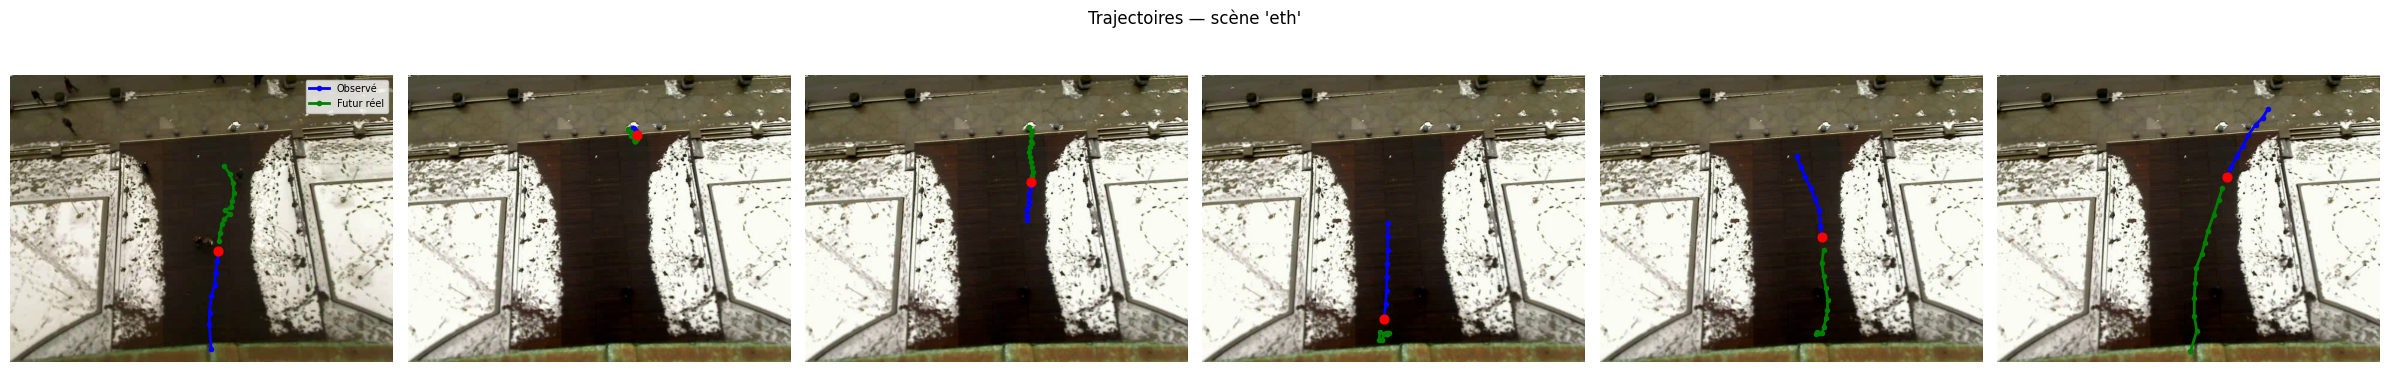

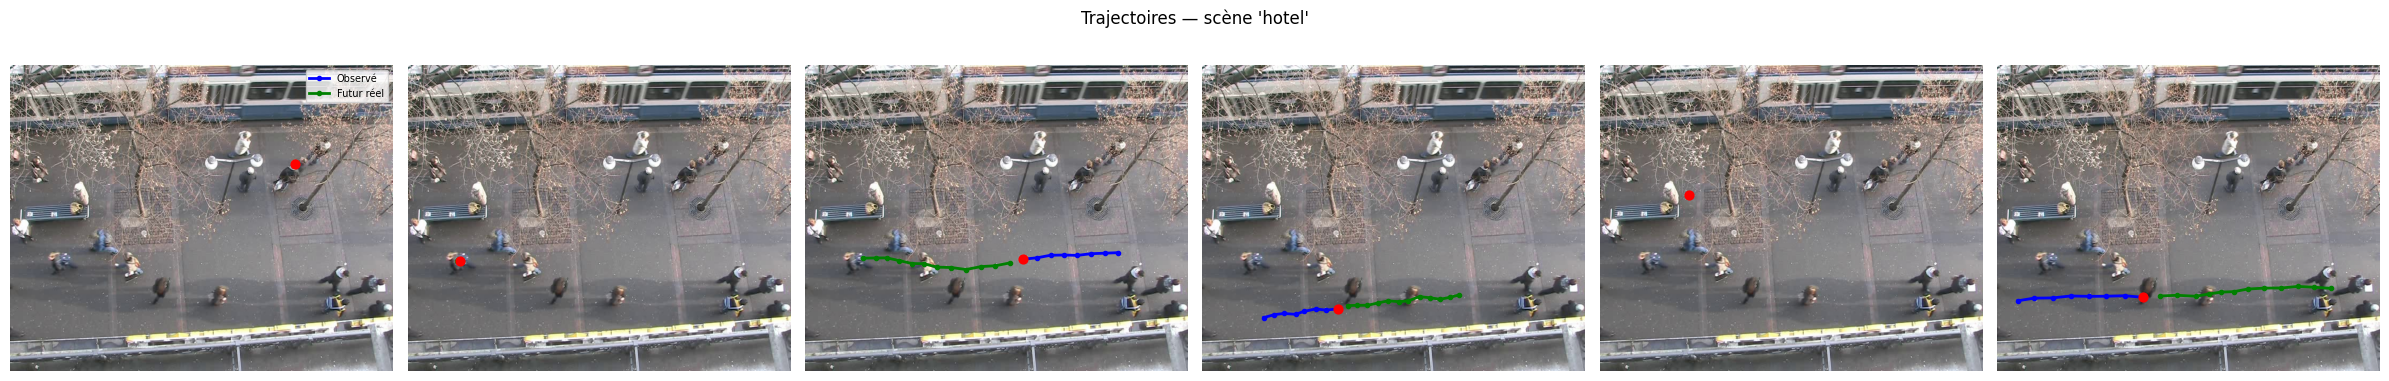

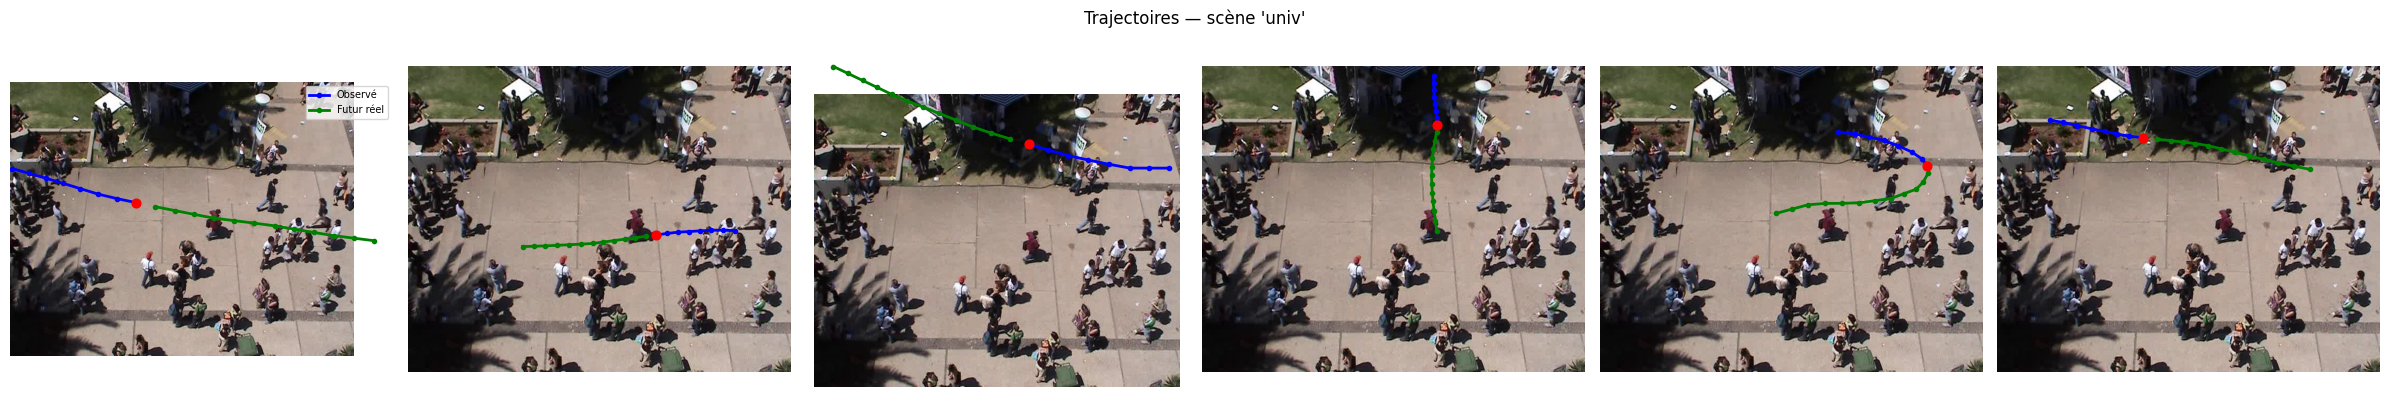

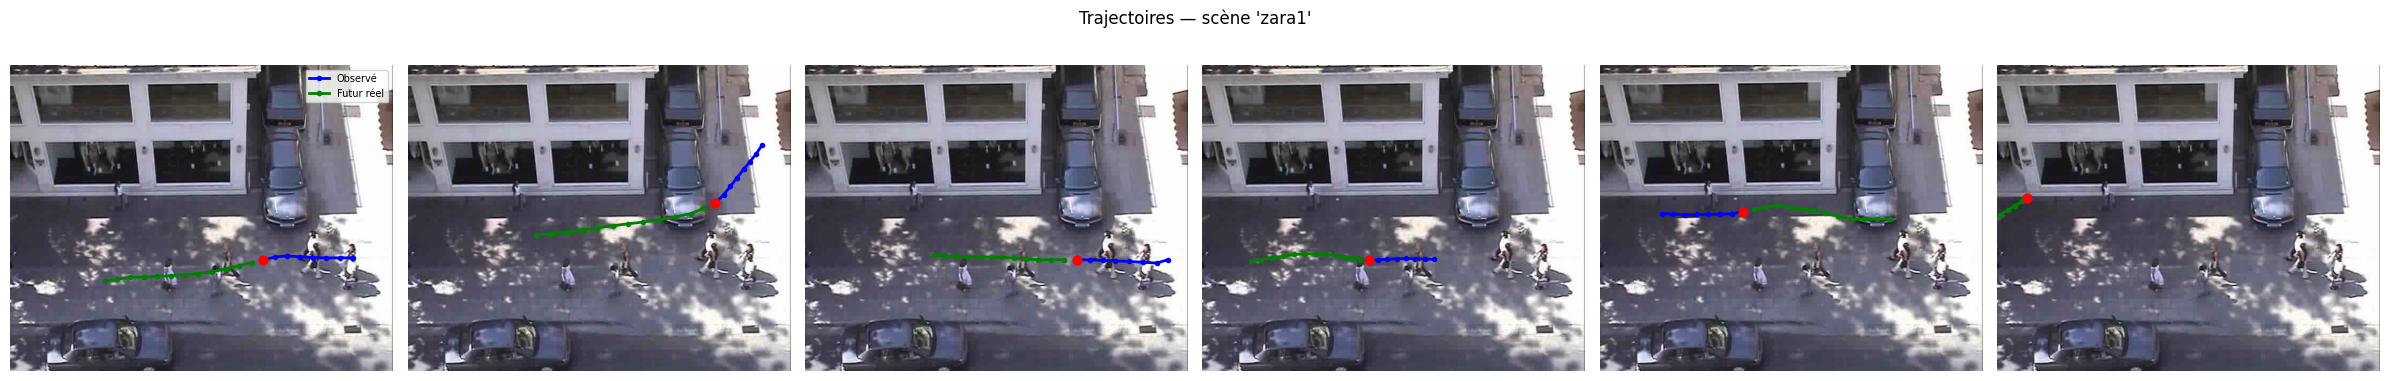

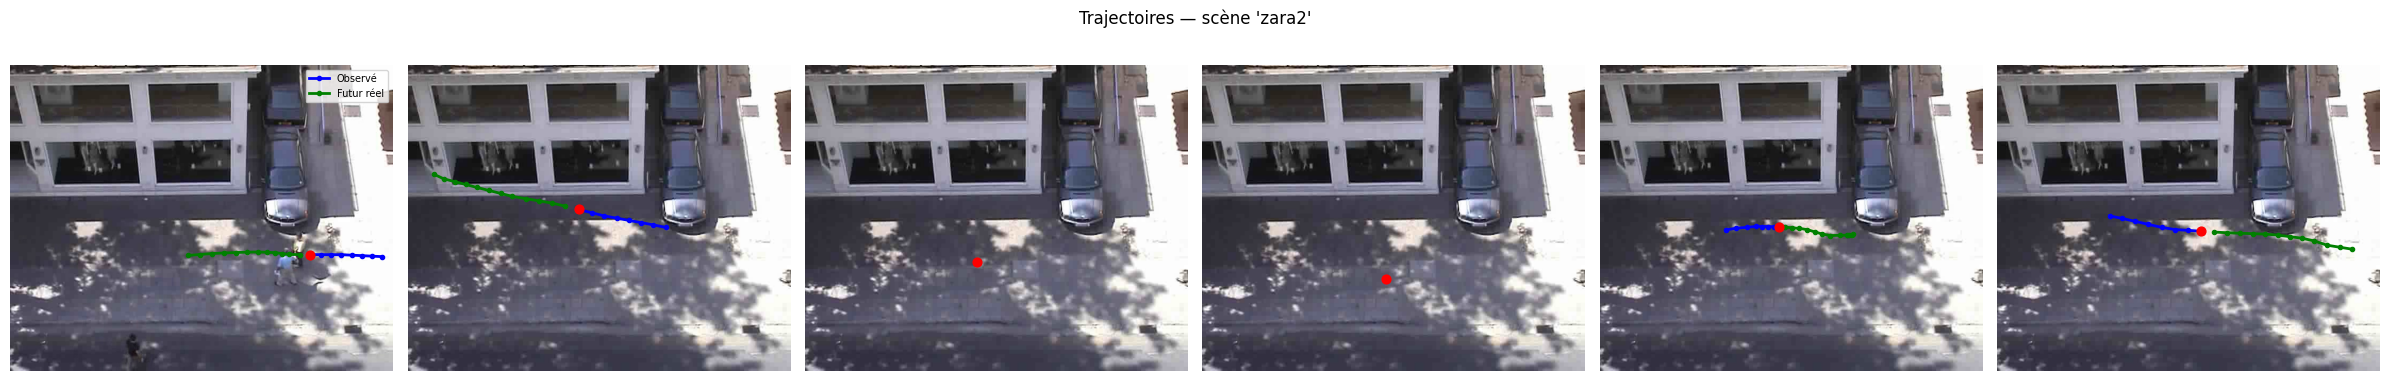

In [4]:
def world_to_pxl(points, H):
    ones  = np.ones((len(points), 1))
    pts_h = np.hstack([points, ones])
    proj  = (H @ pts_h.T).T
    px    = proj[:, 0] / proj[:, 2]
    py    = proj[:, 1] / proj[:, 2]
    return np.stack([px, py], axis=1)

def visualiser_scene(nom_scene, n_trajectoires=6):
    scene   = scenes[nom_scene]
    H       = homographies[nom_scene]
    donnees = charger_fichier(scene["txt"])
    liste_obs, liste_futur = extraire_trajectoires(donnees)

    frame_ids = []
    for ped_id in np.unique(donnees[:, 1]):
        ped = donnees[donnees[:, 1] == ped_id]
        ped = ped[ped[:, 0].argsort()]
        for i in range(0, len(ped) - 20 + 1):
            frame_ids.append(ped[i, 0])

    indices = np.linspace(0, len(liste_obs)-1, n_trajectoires, dtype=int)

    fig, axes = plt.subplots(1, n_trajectoires, figsize=(4*n_trajectoires, 4))
    if n_trajectoires == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        frame_id     = frame_ids[idx]
        nom_frame    = f"frame{int(frame_id * 10):06d}.jpg"
        chemin_frame = os.path.join(scene["image"], nom_frame)
        if not os.path.exists(chemin_frame):
            chemin_frame = os.path.join(scene["image"], "frame000000.jpg")

        ax.imshow(np.array(Image.open(chemin_frame).convert("RGB")))
        obs_px   = world_to_pxl(liste_obs[idx],   H)
        futur_px = world_to_pxl(liste_futur[idx], H)
        ax.plot(obs_px[:,0],   obs_px[:,1],   'b-o', ms=3, lw=2, label='Observé')
        ax.plot(futur_px[:,0], futur_px[:,1], 'g-o', ms=3, lw=2, label='Futur réel')
        ax.scatter(obs_px[-1,0], obs_px[-1,1], color='red', s=40, zorder=5)
        ax.axis('off')

    axes[0].legend(fontsize=7)
    plt.suptitle(f"Trajectoires — scène '{nom_scene}'")
    plt.tight_layout()
    plt.savefig(f"viz_{nom_scene}.png", dpi=150, bbox_inches='tight')
    plt.show()

for scene in ["eth", "hotel", "univ", "zara1", "zara2"]:
    visualiser_scene(scene)

In [5]:
def calcul_ade(pred, futur):
    if isinstance(pred,  torch.Tensor): pred  = pred.numpy()
    if isinstance(futur, torch.Tensor): futur = futur.numpy()
    diff = pred - futur
    return np.sqrt((diff**2).sum(axis=-1)).mean()

def calcul_fde(pred, futur):
    if isinstance(pred,  torch.Tensor): pred  = pred.numpy()
    if isinstance(futur, torch.Tensor): futur = futur.numpy()
    diff = pred[..., -1, :] - futur[..., -1, :]
    return np.sqrt((diff**2).sum(axis=-1)).mean()

def prediction_vitesse_constante(obs):
    if isinstance(obs, torch.Tensor): obs = obs.numpy()
    single = (obs.ndim == 2)
    if single: obs = obs[np.newaxis]
    predictions = np.zeros((len(obs), 12, 2))
    for i, traj in enumerate(obs):
        vitesse = (traj[1:] - traj[:-1]).mean(axis=0)
        pos = traj[-1].copy()
        for t in range(12):
            pos = pos + vitesse
            predictions[i, t] = pos
    return predictions[0] if single else predictions

chargeur = DataLoader(dataset_eval, batch_size=64, shuffle=False)
ades, fdes = [], []
for obs, futur in chargeur:
    pred = prediction_vitesse_constante(obs)
    ades.append(calcul_ade(pred, futur.numpy()))
    fdes.append(calcul_fde(pred, futur.numpy()))

baseline_ade = np.mean(ades)
baseline_fde = np.mean(fdes)
print(f"Baseline — ADE : {baseline_ade:.4f} | FDE : {baseline_fde:.4f}")

Baseline — ADE : 0.3107 | FDE : 0.6550


Epoch 10/50 | Train: 0.2589 | Val: 0.8224
Epoch 20/50 | Train: 0.1887 | Val: 0.7856
Epoch 30/50 | Train: 0.1419 | Val: 0.6088
Epoch 40/50 | Train: 0.0554 | Val: 0.4511
Epoch 50/50 | Train: 0.0308 | Val: 0.4228


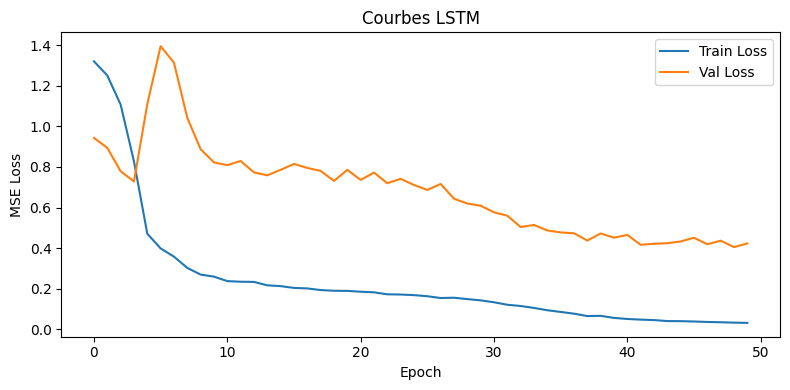

LSTM     — ADE : 0.7700 | FDE : 1.3375
Baseline — ADE : 0.3107 | FDE : 0.6550


In [6]:
import torch.nn as nn

class ModèleLSTM(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, num_layers=1, pred_len=12):
        super().__init__()
        self.pred_len   = pred_len
        self.hidden_dim = hidden_dim
        self.input_fc   = nn.Linear(input_dim, hidden_dim)
        self.encoder    = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True)
        self.decoder    = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True)
        self.output_fc  = nn.Linear(hidden_dim, input_dim)

    def forward(self, obs):
        B = obs.shape[0]
        _, hidden = self.encoder(self.input_fc(obs))
        dec_in    = torch.zeros(B, 1, self.hidden_dim).to(obs.device)
        preds     = []
        for _ in range(self.pred_len):
            out, hidden = self.decoder(dec_in, hidden)
            pos         = self.output_fc(out)
            preds.append(pos)
            dec_in      = self.input_fc(pos)
        return torch.cat(preds, dim=1)

nb_epochs  = 50
hidden_dim = 64
lr         = 1e-3

modele_lstm    = ModèleLSTM(hidden_dim=hidden_dim).to(appareil)
optimiseur     = torch.optim.Adam(modele_lstm.parameters(), lr=lr)
critere        = nn.MSELoss()
chargeur_train = DataLoader(dataset_train, batch_size=64, shuffle=True)
chargeur_eval  = DataLoader(dataset_eval,  batch_size=64, shuffle=False)

pertes_train, pertes_val = [], []
for epoch in range(nb_epochs):
    modele_lstm.train()
    perte_ep = 0
    for obs, futur in chargeur_train:
        obs, futur = obs.to(appareil), futur.to(appareil)
        optimiseur.zero_grad()
        perte = critere(modele_lstm(obs), futur)
        perte.backward()
        optimiseur.step()
        perte_ep += perte.item()
    pertes_train.append(perte_ep / len(chargeur_train))

    modele_lstm.eval()
    perte_val = 0
    with torch.no_grad():
        for obs, futur in chargeur_eval:
            perte_val += critere(modele_lstm(obs.to(appareil)), futur.to(appareil)).item()
    pertes_val.append(perte_val / len(chargeur_eval))

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{nb_epochs} | Train: {pertes_train[-1]:.4f} | Val: {pertes_val[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(pertes_train, label='Train Loss')
plt.plot(pertes_val,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Courbes LSTM')
plt.legend(); plt.tight_layout()
plt.savefig('learning_curves_lstm.png', dpi=150)
plt.show()

modele_lstm.eval()
ades, fdes = [], []
with torch.no_grad():
    for obs, futur in chargeur_eval:
        pred = modele_lstm(obs.to(appareil)).cpu().numpy()
        ades.append(calcul_ade(pred, futur.numpy()))
        fdes.append(calcul_fde(pred, futur.numpy()))
lstm_ade = np.mean(ades)
lstm_fde = np.mean(fdes)
print(f"LSTM     — ADE : {lstm_ade:.4f} | FDE : {lstm_fde:.4f}")
print(f"Baseline — ADE : {baseline_ade:.4f} | FDE : {baseline_fde:.4f}")

Dataset scène chargé : 246 séquences
Dataset scène chargé : 99 séquences
Epoch 10/50 | Train: 0.2329 | Val: 0.8453
Epoch 20/50 | Train: 0.1661 | Val: 0.7514
Epoch 30/50 | Train: 0.1201 | Val: 0.5765
Epoch 40/50 | Train: 0.0424 | Val: 0.4659
Epoch 50/50 | Train: 0.0244 | Val: 0.4211


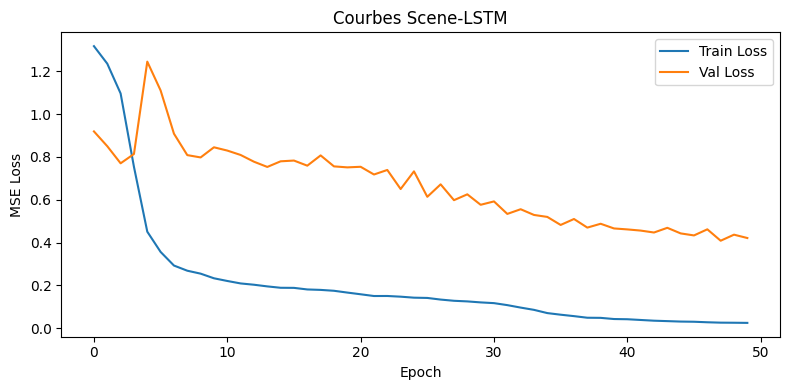

Scene-LSTM — ADE : 0.7470 | FDE : 1.2994
LSTM       — ADE : 0.7700 | FDE : 1.3375


In [7]:
import torchvision.models as models
import torchvision.transforms as transforms

transformation_image = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class EncodeurScene(nn.Module):
    def __init__(self, feat_dim=64):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        for p in self.backbone.parameters(): p.requires_grad = False
        self.proj = nn.Linear(512, feat_dim)

    def forward(self, img):
        with torch.no_grad():
            f = self.backbone(img).squeeze(-1).squeeze(-1)
        return self.proj(f)

class LSTMAvecScene(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, scene_dim=64, pred_len=12):
        super().__init__()
        self.pred_len       = pred_len
        self.hidden_dim     = hidden_dim
        self.encodeur_scene = EncodeurScene(scene_dim)
        self.input_fc       = nn.Linear(input_dim, hidden_dim)
        self.encoder        = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.fusion_fc      = nn.Linear(hidden_dim + scene_dim, hidden_dim)
        self.decoder        = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.output_fc      = nn.Linear(hidden_dim, input_dim)

    def forward(self, obs, img_scene):
        B = obs.shape[0]
        feat_scene = self.encodeur_scene(img_scene)
        _, hidden  = self.encoder(self.input_fc(obs))
        h = hidden[0].squeeze(0)
        h = torch.relu(self.fusion_fc(torch.cat([h, feat_scene], dim=-1))).unsqueeze(0)
        hidden = (h, hidden[1])
        dec_in = torch.zeros(B, 1, self.hidden_dim).to(obs.device)
        preds  = []
        for _ in range(self.pred_len):
            out, hidden = self.decoder(dec_in, hidden)
            pos         = self.output_fc(out)
            preds.append(pos)
            dec_in      = self.input_fc(pos)
        return torch.cat(preds, dim=1)

class DatasetAvecScene(Dataset):
    def __init__(self, chemin, chemin_image):
        donnees = charger_fichier(chemin)
        liste_obs, liste_futur = extraire_trajectoires(donnees)
        liste_obs, liste_futur, self.moyenne, self.ecart_type = normaliser(liste_obs, liste_futur)
        self.obs   = [torch.tensor(o, dtype=torch.float32) for o in liste_obs]
        self.futur = [torch.tensor(f, dtype=torch.float32) for f in liste_futur]
        img = Image.open(chemin_image).convert("RGB")
        self.scene = transformation_image(img)
        print(f"Dataset scène chargé : {len(self.obs)} séquences")

    def __len__(self): return len(self.obs)
    def __getitem__(self, idx): return self.obs[idx], self.futur[idx], self.scene

dataset_scene_train  = DatasetAvecScene(Fichier_Train, Image_Scene)
dataset_scene_eval   = DatasetAvecScene(Fichier_Val,   Image_Scene)
chargeur_scene_train = DataLoader(dataset_scene_train, batch_size=64, shuffle=True)
chargeur_scene_eval  = DataLoader(dataset_scene_eval,  batch_size=64, shuffle=False)

modele_scene = LSTMAvecScene().to(appareil)
optimiseur_s = torch.optim.Adam(modele_scene.parameters(), lr=lr)

pertes_train_s, pertes_val_s = [], []
for epoch in range(nb_epochs):
    modele_scene.train()
    perte_ep = 0
    for obs, futur, scene in chargeur_scene_train:
        obs, futur, scene = obs.to(appareil), futur.to(appareil), scene.to(appareil)
        optimiseur_s.zero_grad()
        perte = critere(modele_scene(obs, scene), futur)
        perte.backward()
        optimiseur_s.step()
        perte_ep += perte.item()
    pertes_train_s.append(perte_ep / len(chargeur_scene_train))

    modele_scene.eval()
    perte_val = 0
    with torch.no_grad():
        for obs, futur, scene in chargeur_scene_eval:
            perte_val += critere(modele_scene(obs.to(appareil), scene.to(appareil)), futur.to(appareil)).item()
    pertes_val_s.append(perte_val / len(chargeur_scene_eval))

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{nb_epochs} | Train: {pertes_train_s[-1]:.4f} | Val: {pertes_val_s[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(pertes_train_s, label='Train Loss')
plt.plot(pertes_val_s,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Courbes Scene-LSTM')
plt.legend(); plt.tight_layout()
plt.savefig('learning_curves_scene.png', dpi=150)
plt.show()

modele_scene.eval()
ades, fdes = [], []
with torch.no_grad():
    for obs, futur, scene in chargeur_scene_eval:
        pred = modele_scene(obs.to(appareil), scene.to(appareil)).cpu().numpy()
        ades.append(calcul_ade(pred, futur.numpy()))
        fdes.append(calcul_fde(pred, futur.numpy()))
scene_ade = np.mean(ades)
scene_fde = np.mean(fdes)
print(f"Scene-LSTM — ADE : {scene_ade:.4f} | FDE : {scene_fde:.4f}")
print(f"LSTM       — ADE : {lstm_ade:.4f} | FDE : {lstm_fde:.4f}")

Epoch 20/100 | G: 0.9525 | D: 0.5875
Epoch 40/100 | G: 1.2384 | D: 0.5356
Epoch 60/100 | G: 0.8351 | D: 0.6457
Epoch 80/100 | G: 0.7473 | D: 0.6623
Epoch 100/100 | G: 0.8773 | D: 0.6190


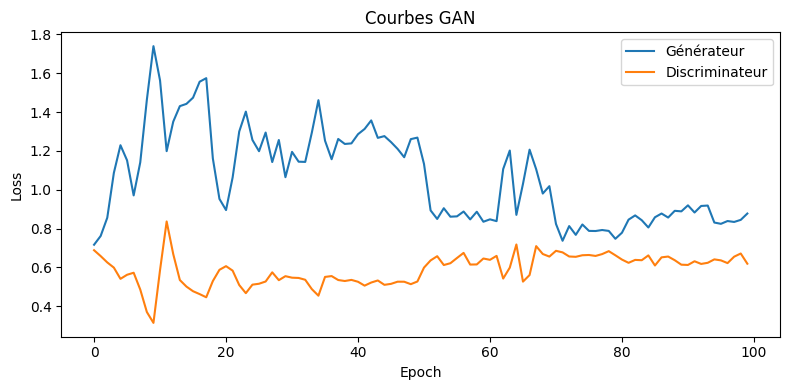

In [8]:
class Generateur(nn.Module):
    def __init__(self, hidden_dim=64, noise_dim=16, pred_len=12):
        super().__init__()
        self.pred_len   = pred_len
        self.hidden_dim = hidden_dim
        self.noise_dim  = noise_dim
        self.input_fc   = nn.Linear(2, hidden_dim)
        self.encoder    = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.noise_fc   = nn.Linear(hidden_dim + noise_dim, hidden_dim)
        self.decoder    = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.output_fc  = nn.Linear(hidden_dim, 2)

    def forward(self, obs, z=None):
        B = obs.shape[0]
        if z is None: z = torch.randn(B, self.noise_dim).to(obs.device)
        _, hidden = self.encoder(self.input_fc(obs))
        h = hidden[0].squeeze(0)
        h = torch.relu(self.noise_fc(torch.cat([h, z], dim=-1))).unsqueeze(0)
        hidden = (h, hidden[1])
        dec_in = torch.zeros(B, 1, self.hidden_dim).to(obs.device)
        preds  = []
        for _ in range(self.pred_len):
            out, hidden = self.decoder(dec_in, hidden)
            pos         = self.output_fc(out)
            preds.append(pos)
            dec_in      = self.input_fc(pos)
        return torch.cat(preds, dim=1)

class Discriminateur(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.input_fc  = nn.Linear(2, hidden_dim)
        self.lstm      = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.output_fc = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, traj):
        _, hidden = self.lstm(self.input_fc(traj))
        return self.output_fc(hidden[0].squeeze(0))

nb_epochs_gan  = 100
generateur     = Generateur().to(appareil)
discriminateur = Discriminateur().to(appareil)
opt_G = torch.optim.Adam(generateur.parameters(),     lr=1e-3, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(discriminateur.parameters(), lr=1e-3, betas=(0.5, 0.999))
bce   = nn.BCEWithLogitsLoss()

pertes_g, pertes_d = [], []
for epoch in range(nb_epochs_gan):
    generateur.train(); discriminateur.train()
    g_ep = d_ep = 0
    for obs, futur in chargeur_train:
        obs, futur = obs.to(appareil), futur.to(appareil)
        B = obs.shape[0]

        discriminateur.zero_grad()
        real_traj = torch.cat([obs, futur], dim=1)
        fake_traj = torch.cat([obs, generateur(obs).detach()], dim=1)
        loss_D = (bce(discriminateur(real_traj), torch.ones(B, 1, device=appareil)) +
                  bce(discriminateur(fake_traj), torch.zeros(B, 1, device=appareil))) / 2
        loss_D.backward()
        opt_D.step()

        generateur.zero_grad()
        fake_traj = torch.cat([obs, generateur(obs)], dim=1)
        loss_G = bce(discriminateur(fake_traj), torch.ones(B, 1, device=appareil))
        loss_G.backward()
        opt_G.step()

        g_ep += loss_G.item(); d_ep += loss_D.item()

    pertes_g.append(g_ep / len(chargeur_train))
    pertes_d.append(d_ep / len(chargeur_train))
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{nb_epochs_gan} | G: {pertes_g[-1]:.4f} | D: {pertes_d[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(pertes_g, label='Générateur')
plt.plot(pertes_d, label='Discriminateur')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Courbes GAN')
plt.legend(); plt.tight_layout()
plt.savefig('gan_curves.png', dpi=150)
plt.show()

GAN Best-of-20 — ADE : 1.2015 | FDE : 1.8346
Diversité : 0.0001


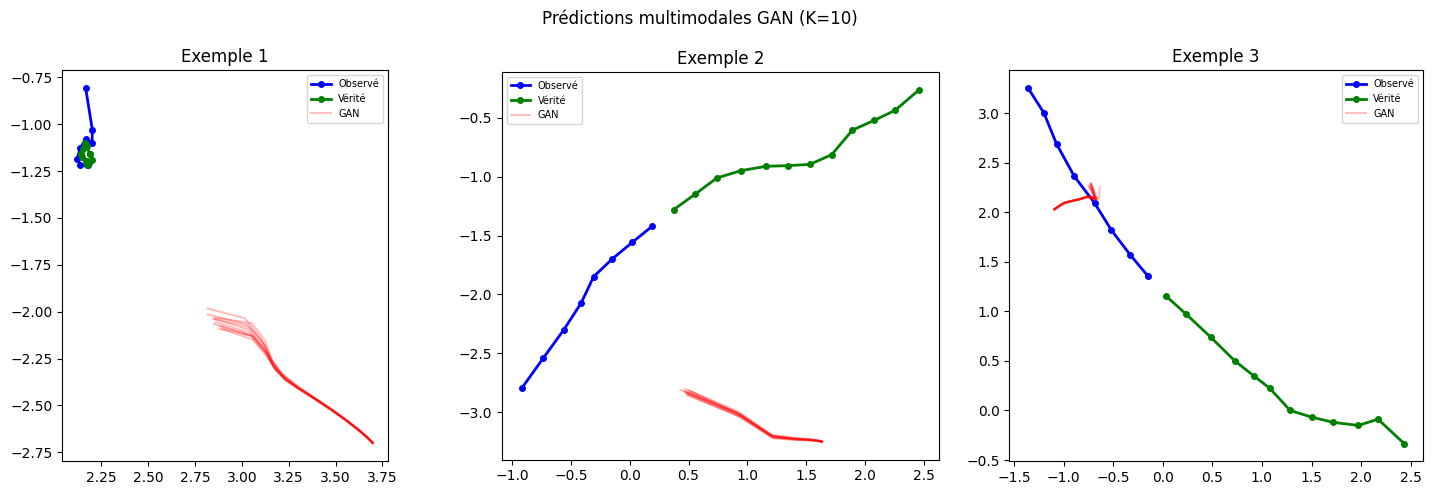

In [9]:
K = 20
generateur.eval()
all_ade, all_fde, all_div = [], [], []

with torch.no_grad():
    for obs, futur in chargeur_eval:
        obs_d  = obs.to(appareil)
        futur  = futur.numpy()
        k_preds = np.stack([generateur(obs_d).cpu().numpy() for _ in range(K)], axis=1)
        for i in range(len(obs)):
            ades = [calcul_ade(k_preds[i,k], futur[i]) for k in range(K)]
            best = np.argmin(ades)
            all_ade.append(min(ades))
            all_fde.append(calcul_fde(k_preds[i, best], futur[i]))
            all_div.append(k_preds[i].var(axis=0).mean())

gan_ade   = np.mean(all_ade)
gan_fde   = np.mean(all_fde)
diversite = np.mean(all_div)
print(f"GAN Best-of-{K} — ADE : {gan_ade:.4f} | FDE : {gan_fde:.4f}")
print(f"Diversité : {diversite:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax_i, idx in enumerate([0, len(dataset_eval)//2, len(dataset_eval)-1]):
    obs, futur = dataset_eval[idx]
    ax = axes[ax_i]
    ax.plot(obs.numpy()[:,0],   obs.numpy()[:,1],   'b-o', lw=2, ms=4, label='Observé')
    ax.plot(futur.numpy()[:,0], futur.numpy()[:,1], 'g-o', lw=2, ms=4, label='Vérité')
    obs_t = obs.unsqueeze(0).to(appareil)
    with torch.no_grad():
        for k in range(10):
            pred = generateur(obs_t).cpu().numpy()[0]
            offset = obs.numpy()[-1]  # dernière position observée
            pred_shifted = pred + offset  # recaler la prédiction
            ax.plot(pred_shifted[:,0], pred_shifted[:,1], 'r-', alpha=0.25, label='GAN' if k==0 else '')
    ax.set_title(f'Exemple {ax_i+1}')
    ax.legend(fontsize=7)
    ax.set_aspect('equal')

plt.suptitle('Prédictions multimodales GAN (K=10)')
plt.tight_layout()
plt.savefig('multimodal_viz.png', dpi=150)
plt.show()

  Modèle                         ADE      FDE  Diversité
───────────────────────────────────────────────────────
  Baseline (vitesse cte)      0.3107   0.6550          -
  LSTM                        0.7700   1.3375          -
  Scene-LSTM                  0.7470   1.2994          -
  GAN Best-of-20              1.2015   1.8346     0.0001


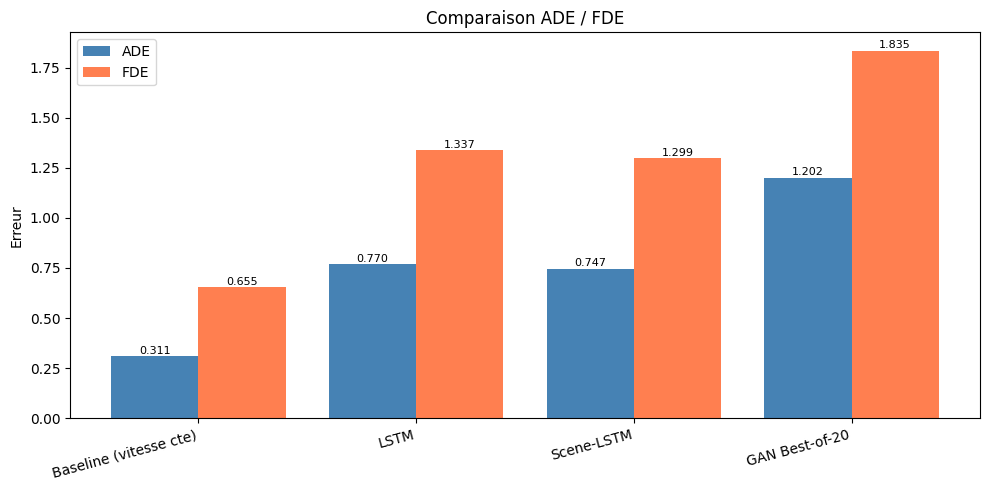

In [10]:
resultats = [
    ("Baseline (vitesse cte)", baseline_ade, baseline_fde, "-"),
    ("LSTM",                   lstm_ade,     lstm_fde,     "-"),
    ("Scene-LSTM",             scene_ade,    scene_fde,    "-"),
    (f"GAN Best-of-{K}",       gan_ade,      gan_fde,      f"{diversite:.4f}"),
]

print(f"  {'Modèle':<25} {'ADE':>8} {'FDE':>8} {'Diversité':>10}")
print("─" * 55)
for nom, ade, fde, div in resultats:
    print(f"  {nom:<25} {ade:>8.4f} {fde:>8.4f} {div:>10}")

noms = [r[0] for r in resultats]
ades = [r[1] for r in resultats]
fdes = [r[2] for r in resultats]

x = np.arange(len(noms))
fig, ax = plt.subplots(figsize=(10, 5))
barres1 = ax.bar(x - 0.2, ades, 0.4, label='ADE', color='steelblue')
barres2 = ax.bar(x + 0.2, fdes, 0.4, label='FDE', color='coral')
ax.set_xticks(x); ax.set_xticklabels(noms, rotation=15, ha='right')
ax.set_ylabel('Erreur')
ax.set_title('Comparaison ADE / FDE')
ax.legend()
for b in barres1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002, f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for b in barres2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002, f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()